#### Polynomial Regression (Practice Exercises)

In [23]:
from pathlib import Path
import sys

current_dir = Path.cwd()
project_root = current_dir.parent.absolute()

sys.path.insert(0,str(project_root))

from config import POLY_DS_P

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy 
import seaborn as sns

In [25]:
#loading the dataset
df= pd.read_csv(POLY_DS_P)
print(f'Shape of the Dataset: {df.shape}')
print(f'Missing values in the each columns: \n{df.isnull().sum()}')
df.head()

Shape of the Dataset: (102, 2)
Missing values in the each columns: 
Temperature_C    0
IceCreamSales    0
dtype: int64


,Temperature_C,IceCreamSales
0,5.2,180
1,6.1,195
2,7.0,210
3,7.8,230
4,8.5,220


##### EDA Visualization


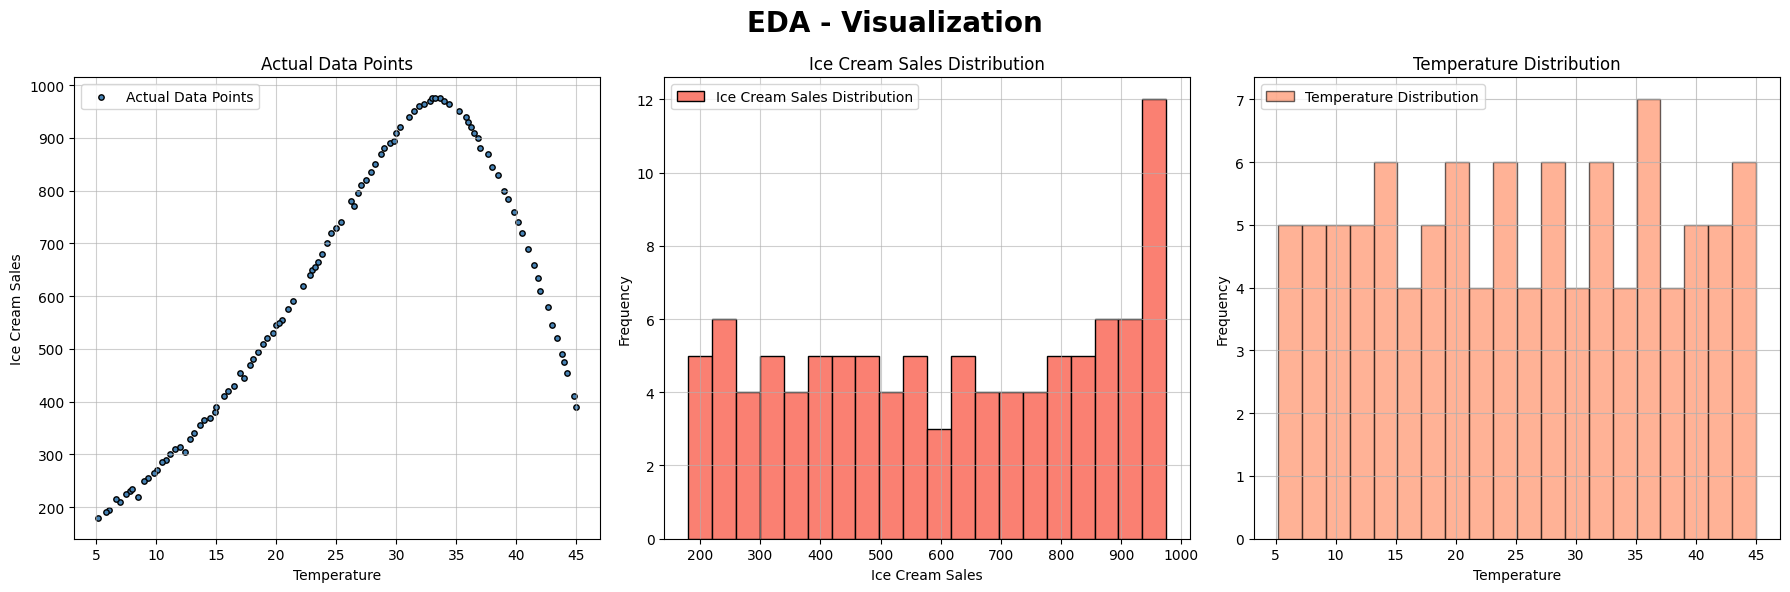

In [26]:
fig, axes = plt.subplots(1,3,figsize=(18,6))
plt.suptitle('EDA - Visualization', fontsize=20, fontweight='bold')

axes[0].scatter(df['Temperature_C'],df['IceCreamSales'],marker='.',color='steelblue',label='Actual Data Points',s=60, edgecolor='k')
axes[0].set_ylabel('Ice Cream Sales')
axes[0].set_xlabel('Temperature')
axes[0].set_title('Actual Data Points')
axes[0].grid(True,alpha=0.6)
axes[0].legend()

#plot2: Histogram (sales distribution)
axes[1].hist(df['IceCreamSales'],bins=20,color='salmon',edgecolor='k',label='Ice Cream Sales Distribution')
axes[1].set_ylabel('Frequency')
axes[1].set_xlabel('Ice Cream Sales')
axes[1].set_title('Ice Cream Sales Distribution')
axes[1].grid(True,alpha=0.6)
axes[1].legend()


#plot3: Temperature Distribution
axes[2].hist(df['Temperature_C'],color='coral',label='Temperature Distribution',edgecolor='k',alpha=0.6,bins=20)
axes[2].set_ylabel('Frequency')
axes[2].set_xlabel('Temperature')
axes[2].set_title('Temperature Distribution')
axes[2].legend()
axes[2].grid(True,alpha=0.7)

plt.tight_layout()
plt.show()

##### Data Preprocessing and Model Training

In [27]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline 
from sklearn.linear_model import LinearRegression

X = df[['Temperature_C']].values
y = df['IceCreamSales']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)



#### Model Training and Comparing Different degrees

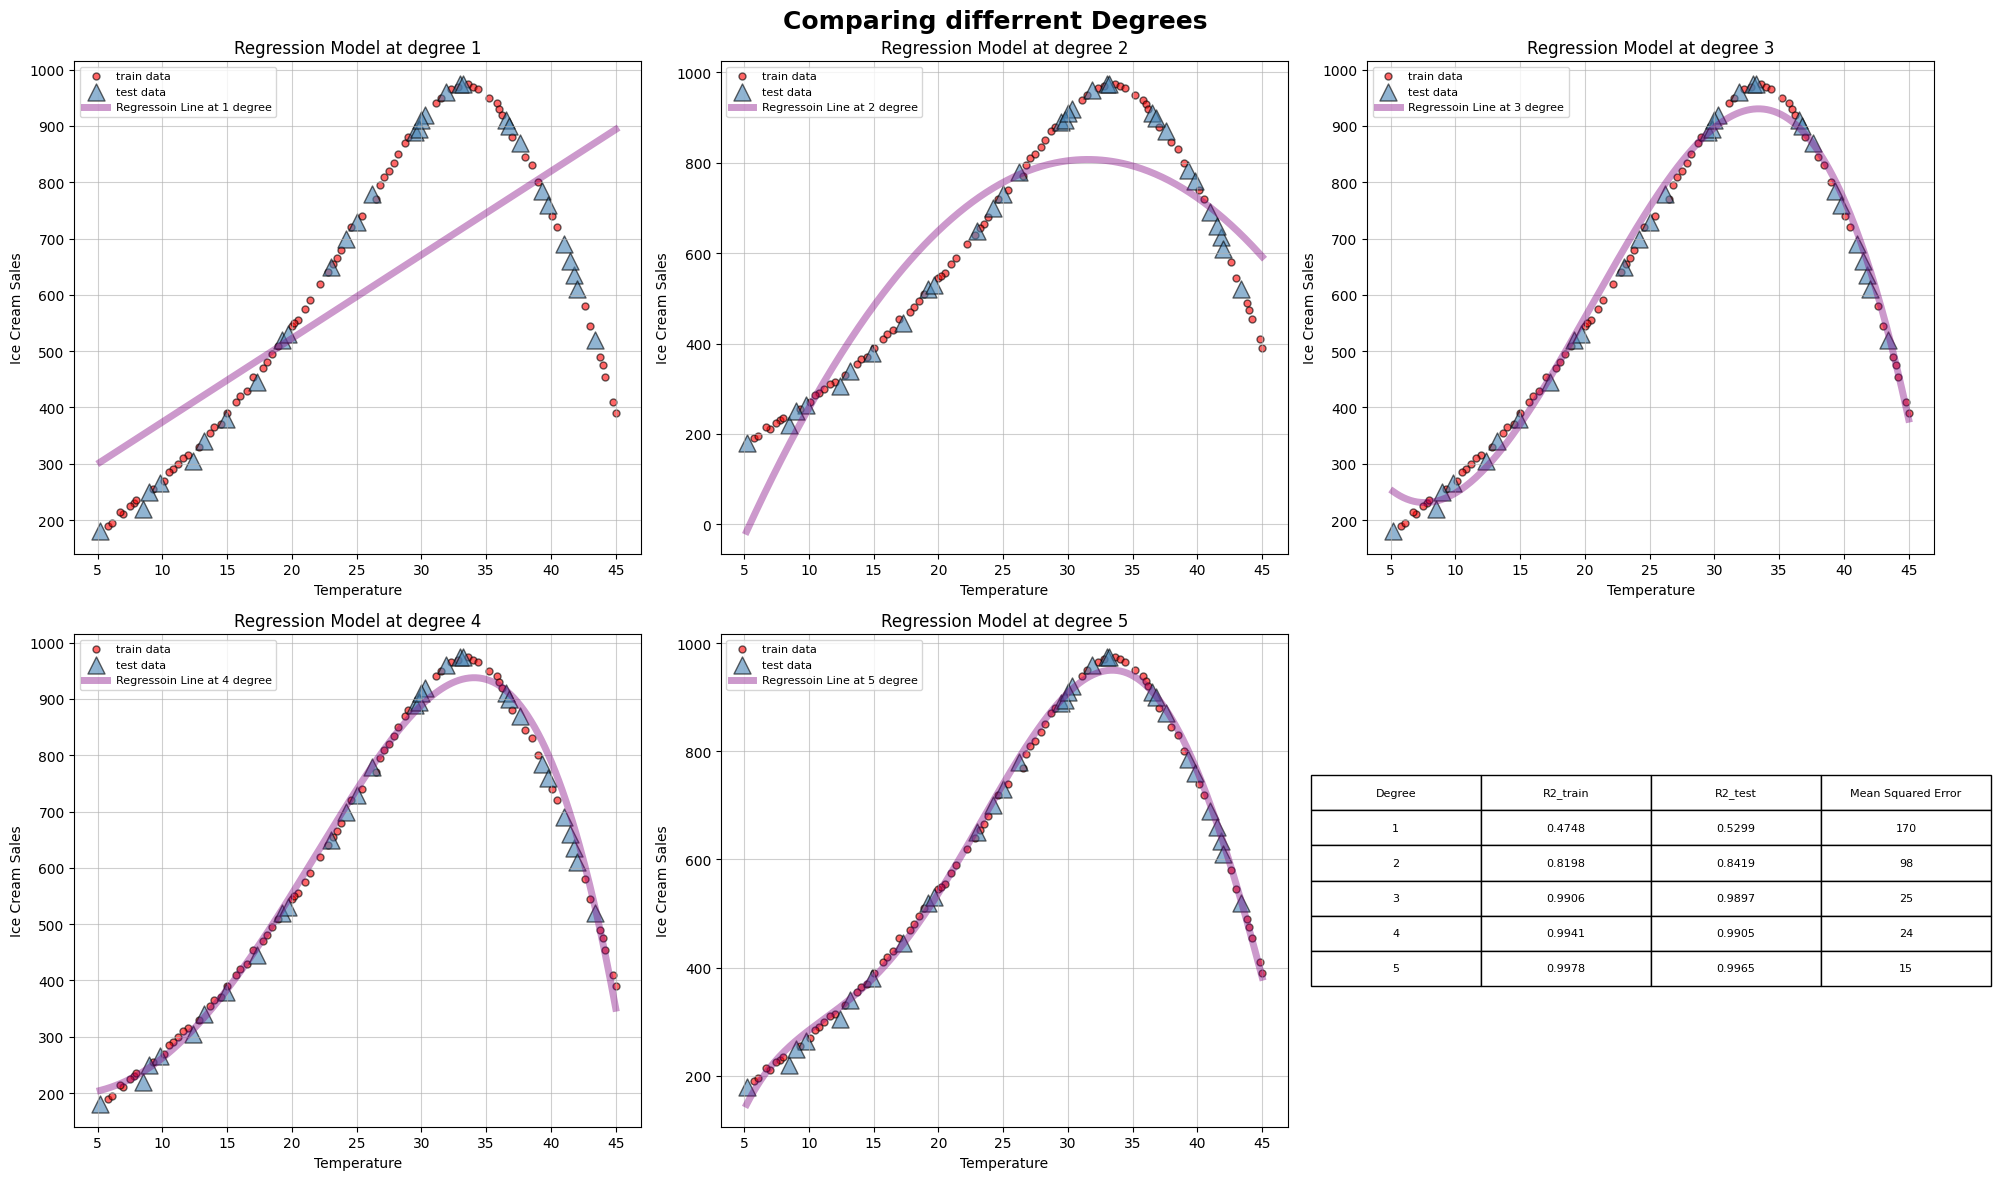

In [28]:
from sklearn.metrics import r2_score , mean_squared_error

degrees = [1,2,3,4,5]
results = {}

fig, axes = plt.subplots(2,3,figsize=(20,12))
fig.suptitle('Comparing differrent Degrees', fontsize=18,fontweight='bold')

X_plot = np.linspace(X.min(), X.max(),300).reshape(-1,1)

for idx, degree in enumerate(degrees):
    pipeline = Pipeline([
        ('poly' , PolynomialFeatures(degree=degree)),
        ('linear' , LinearRegression())
    ])

    pipeline.fit(X_train,y_train)

    # predict

    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)
    y_pred_plot = pipeline.predict(X_plot)

    # r2 score

    r2_train = r2_score(y_train,y_pred_train)
    r2_test = r2_score(y_test,y_pred_test)
    rmse = np.sqrt(mean_squared_error(y_test,y_pred_test))

    # storing the results
    results[degree] ={
        'r2_train' : r2_train,
        'r2_test' : r2_test,
        'r2_plot' : r2_plot,
        'rmse' : rmse,
        'model' : pipeline
    }

    # plot
    rows, cols = divmod(idx,3)

    axes[rows,cols].scatter(X_train,y_train,label='train data',color='r',marker='.',s=100,alpha=0.6,edgecolor='k')
    axes[rows,cols].scatter(X_test,y_test,label='test data',color='steelblue',marker='^',s=150,alpha=0.6,edgecolor='k')
    axes[rows,cols].plot(X_plot,y_pred_plot,linewidth='5',alpha=0.4,color='purple',label=f'Regressoin Line at {degree} degree')
    axes[rows,cols].set_ylabel('Ice Cream Sales')
    axes[rows,cols].set_xlabel('Temperature')
    axes[rows,cols].set_title(f'Regression Model at degree {degree}')
    axes[rows,cols].legend(fontsize=8)
    axes[rows,cols].grid(True,alpha=0.6)

    axes[1,2].axis('off')

# Comparsion Table
table_data = []
for d, r in results.items():
    row = [d,f'{r['r2_train']:.4f}', f'{r['r2_test']:.4f}', f'{r['rmse']:.0f}']
    table_data.append(row)

table = axes[1,2] = plt.table(
    cellText=table_data, colLabels=['Degree','R2_train','R2_test','Mean Squared Error'],loc='center',cellLoc='center'
)
table.auto_set_font_size('False')
table.set_fontsize(16)
table.scale(1.2,1.8)
# axes[1,2].set_title('Comparsion Table',fontweight='bold')



plt.tight_layout()
plt.show()

#### Best degree 

In [32]:
best_degree = max(results, key=lambda d: results[d]['r2_test'])
print(f'Best Polynomial Degree: {best_degree} R2 Score: {results[best_degree]['r2_test']:.4f}')

best_model = results[best_degree]['model']
y_pred_best = best_model.predict(X_test)

Best Polynomial Degree: 5 R2 Score: 0.9965


#### Final Visualization

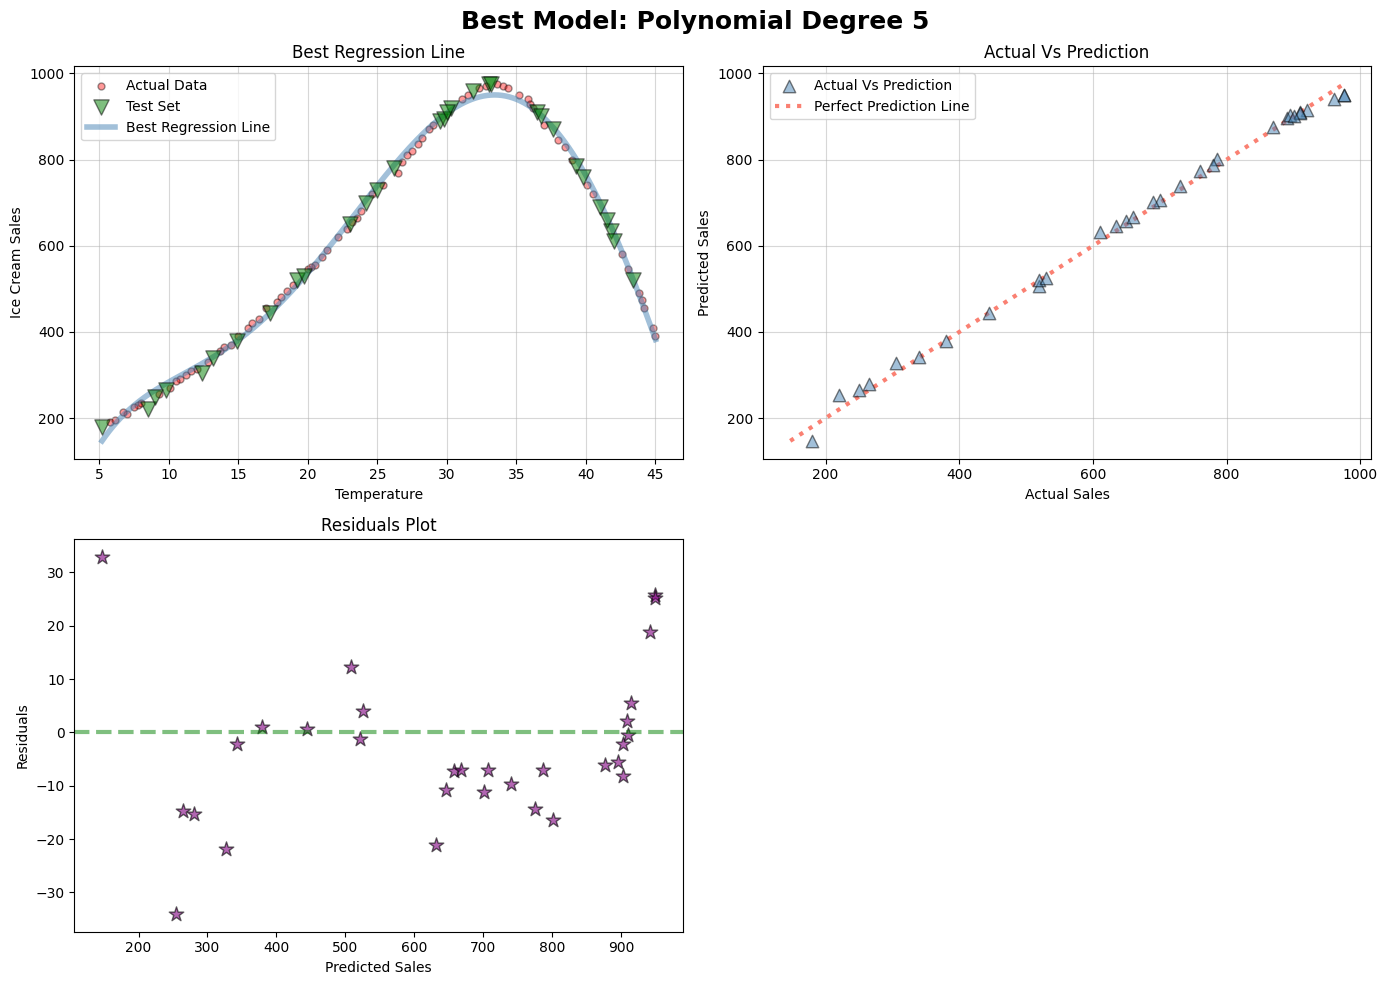

In [39]:
fig, axes = plt.subplots(2,2, figsize=(14,10))
fig.suptitle(f'Best Model: Polynomial Degree {best_degree}',fontweight='bold',fontsize=18)

y_pred_best_plot = best_model.predict(X_plot)
axes[0,0].scatter(X_train,y_train, label='Actual Data',marker='.',color='r',edgecolor='k',s=100,alpha=0.4)
axes[0,0].scatter(X_test,y_test,label='Test Set',s=120,color='green',marker='v',edgecolor='k',alpha=0.5,zorder=5)
axes[0,0].plot(X_plot,y_pred_best_plot,label='Best Regression Line',linewidth=4,color='steelblue',alpha=0.5)
axes[0,0].set_ylabel('Ice Cream Sales')
axes[0,0].set_xlabel('Temperature')
axes[0,0].set_title('Best Regression Line')
axes[0,0].grid(True,alpha=0.5)
axes[0,0].legend()


# actual Vs Prediction 
axes[0,1].scatter(y_test,y_pred_test,marker='^',color="steelblue",label='Actual Vs Prediction',s=80,edgecolor='k',alpha=0.5,zorder=5)
min_y = min(y_test.min(),y_pred_best_plot.min())
max_y = max(y_test.max(),y_pred_best_plot.max())

axes[0,1].plot([min_y,max_y],[min_y,max_y],color='salmon',linestyle=':',lw=3,label='Perfect Prediction Line')
axes[0,1].set_title('Actual Vs Prediction')
axes[0,1].set_ylabel('Predicted Sales')
axes[0,1].set_xlabel('Actual Sales')
axes[0,1].legend()
axes[0,1].grid(True,alpha=0.5)


#residuals plot
residuals = y_test.values - y_pred_best
axes[1,0].scatter(y_pred_best,residuals,marker='*',color='purple',s=120,alpha=0.6,edgecolor='k')
axes[1,0].axhline(y=0,color='green',lw=3,alpha=0.5,linestyle='--')
axes[1,0].set_ylabel('Residuals')
axes[1,0].set_xlabel('Predicted Sales')
axes[1,0].set_title('Residuals Plot')

axes[1,1].axis('off')
plt.tight_layout()
plt.show()